# Hotel Harmony: Data Insights for Optimized Operations

## Objective
 Elite Hotels International needs to optimize its booking patterns and enhance customer satisfaction to maintain a competitive edge in the hospitality industry.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

In [10]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [120]:
df['arrival_date_year'] = df['arrival_date_year'].astype(str)

In [15]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.reset_index(drop=True, inplace=True)

# 1. BASIC

In [20]:
# 1.Average lead time for bookings
print(df['lead_time'].mean())

79.89136802599661


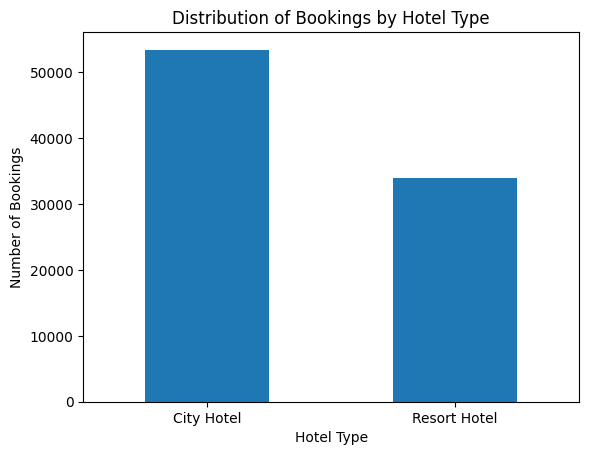

In [33]:
# 2.Distribution of bookings by hotel type
df['hotel'].value_counts().plot(kind='bar')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.title('Distribution of Bookings by Hotel Type')
plt.show()

In [34]:
# 3.No of Bookings were canceled
print(df['is_canceled'].value_counts()[1])

24025


In [38]:
# 4.Most common arrival month for bookings
print(df['arrival_date_month'].mode()[0])

August


In [42]:
# 5.Average number of special requests per booking
print(df['total_of_special_requests'].mean())

0.6985674401574443


In [53]:
# 6.Country with highest number of bookings
df.groupby('country')['is_canceled'].sum().sort_values(ascending=False).head(1)

,is_canceled
country,
PRT,9791


In [54]:
# 7.Average daily rate (ADR) for each hotel type
df.groupby('hotel')['adr'].mean()

,adr
hotel,
City Hotel,110.985944
Resort Hotel,99.025346


In [105]:
# 8.Percentage of guests required car parking spaces
print(((df['required_car_parking_spaces'] > 0).sum() / df['required_car_parking_spaces'].count()) * 100)

8.367659847132591


In [136]:
# 9.Average stay duration in week nights and weekend nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
print(df['total_nights'].mean())

3.6306581536912446


In [70]:
# 10.No of Bookings were made through travel agents
print(df['agent'].count())

75203


# 2. MEDIUM

In [93]:
# 1.Cancellation rate for each hotel type
print(f'Hotel - City Hotel cancelation rate : {(df[df['hotel']=='City Hotel']['is_canceled'].value_counts()[1])/(df[df['hotel']=='City Hotel']['is_canceled'].count())*100}')
print(f'Hotel - Resort Hotel cancelation rate : {(df[df['hotel']=='Resort Hotel']['is_canceled'].value_counts()[1])/(df[df['hotel']=='Resort Hotel']['is_canceled'].count())*100}')

Hotel - City Hotel cancelation rate : 30.03855656210227
Hotel - Resort Hotel cancelation rate : 23.480923221855864


In [96]:
# 2.Average ADR per market segment
df.groupby('market_segment')['adr'].mean()

,adr
market_segment,
Aviation,100.170396
Complementary,3.049245
Corporate,68.151246
Direct,116.579429
Groups,74.864284
Offline TA/TO,81.764191
Online TA,118.171606
Undefined,15.000000


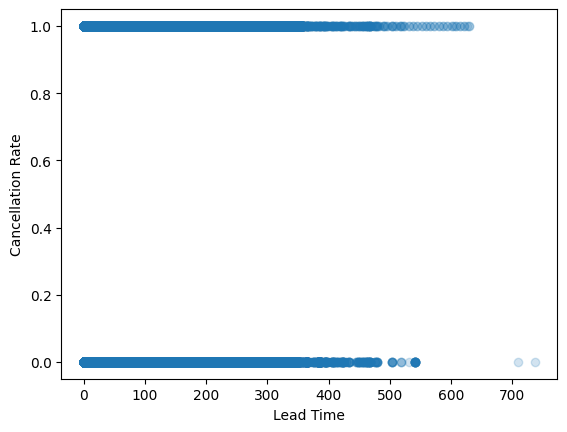

In [122]:
# 3.Relationship between lead time and cancellation rate
plt.scatter(df['lead_time'], df['is_canceled'],alpha=0.2 )
plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate')
plt.show()

In [100]:
# 4.Distribution channel with highest number of bookings
df['distribution_channel'].mode()[0]

'TA/TO'

In [106]:
# 5.Average number of previous cancellations by hotel type
df.groupby('hotel')['previous_cancellations'].mean()

,previous_cancellations
hotel,
City Hotel,0.035768
Resort Hotel,0.021991


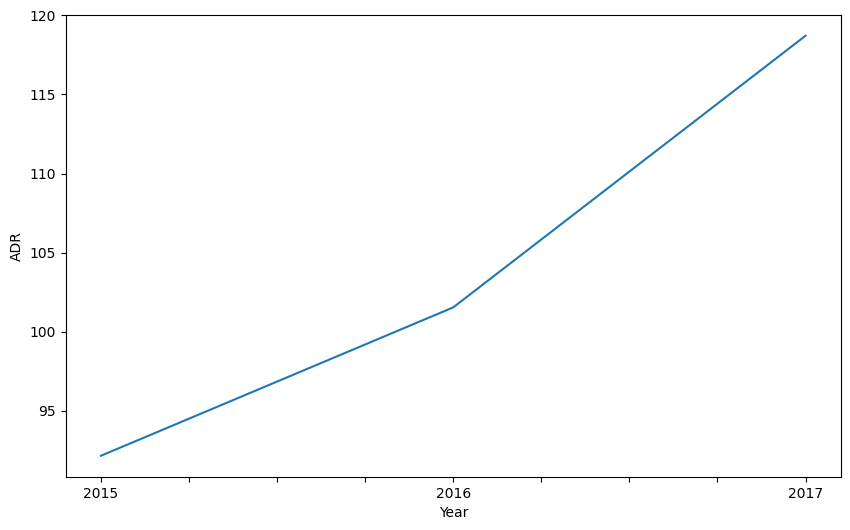

In [121]:
# 6.trend of ADR over the years
plt.figure(figsize=(10, 6))
df.groupby('arrival_date_year')['adr'].mean().plot()
plt.xlabel('Year')
plt.ylabel('ADR')
plt.show()

In [124]:
# 7.Month with highest revenue
df.groupby('arrival_date_month')['adr'].sum().sort_values(ascending=False)

,adr
arrival_date_month,
August,1698412.48
July,1363146.03
June,929859.68
May,929040.10
April,819368.35
September,749823.65
October,625117.56
March,613132.35
February,455472.02


In [130]:
# 8.Impact of special requests on ADR
df[['adr','total_of_special_requests']].corr()

,adr,total_of_special_requests
adr,1.000000,0.137831
total_of_special_requests,0.137831,1.000000


In [139]:
# 9.Average stay duration for repeated guests Vs new guests
df.groupby('is_repeated_guest')['total_nights'].mean().rename({0:'New Guests',1:'Repeated Guests'})

,total_nights
is_repeated_guest,
New Guests,3.699932
Repeated Guests,1.927086


In [145]:
# 10.Room type with highest number of bookings
df['reserved_room_type'].value_counts().head(1)

,count
reserved_room_type,
A,56552


# 3. ADVANCED

<Axes: >

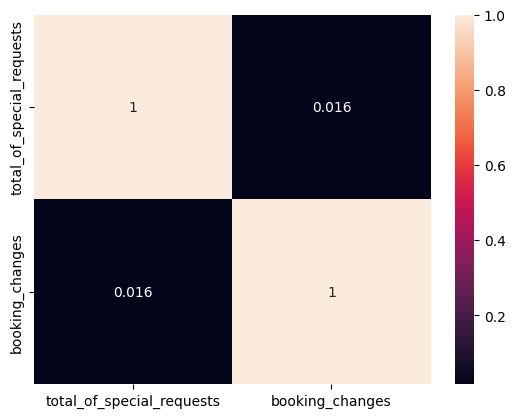

In [151]:
# 3.Impact of booking changes on guest satisfaction as indicated by special requests
sns.heatmap(df[['total_of_special_requests','booking_changes']].corr(), annot=True)

In [171]:
# 4.Seasonal impact on booking cancellations
df['arrival_date_month'].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [167]:
def get_season(month):
    if month in ['December', 'January', 'February']:
        return 'Winter'
    elif month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['arrival_date_month'].apply(get_season)

In [165]:
seasonal_cancel_rate = df.groupby('season')['is_canceled'].mean().sort_values(ascending=False)
seasonal_cancel_rate

,is_canceled
season,
Summer,0.315520
Spring,0.280998
Winter,0.240610
Autumn,0.232988


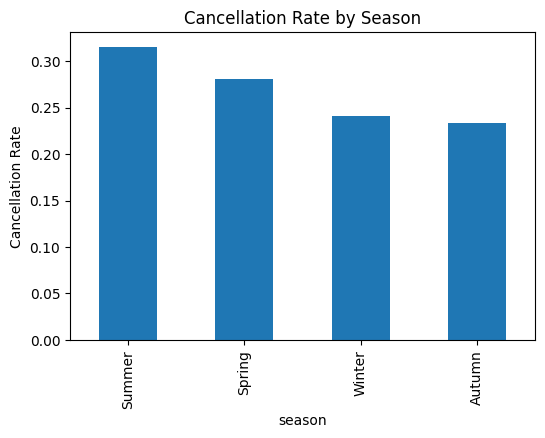

In [166]:
seasonal_cancel_rate.plot(kind='bar', figsize=(6,4))
plt.ylabel("Cancellation Rate")
plt.title("Cancellation Rate by Season")
plt.show()

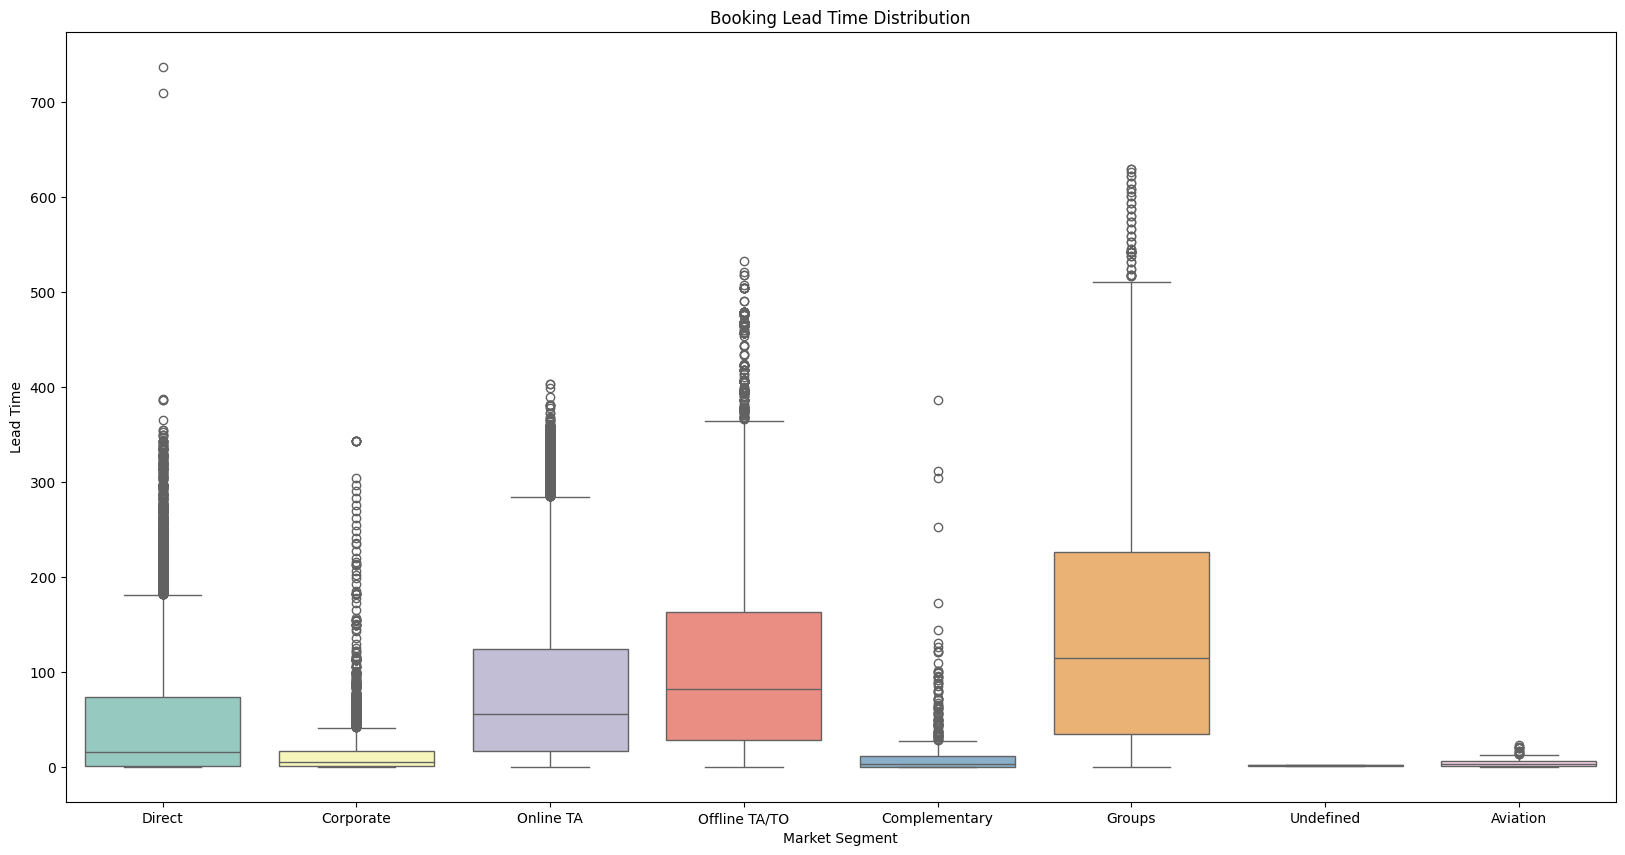

In [161]:
# 5.Booking lead time distribution Vs Different market segments
plt.figure(figsize=(20, 10))
sns.boxplot(x='market_segment', y='lead_time',hue='market_segment', data=df, palette='Set3')
plt.xlabel('Market Segment')
plt.ylabel('Lead Time')
plt.title('Booking Lead Time Distribution')
plt.show()